# **Ievads attēlu apstrādē**

## **Praktiskais darbs Nr. 1**

---

**Students:** Edgars Polis

**Studenta apliecības Nr.:** 241RDB296

**Saite uz programmēšanas kodu:** https://github.com/Edgars-P/RTU_IAA_MD/blob/main/LD1/IAA_LD1.ipynb

---

**Variants 6**

- Atņemšana (Subtraction / Linear Burn)
- Reizināšana (Multiply)
- Izgaismošana (Dodge / Color Dodge)
- Caurspīdīguma maiņa (Transparency/Opacity)


## **Programmas kods ar izvadi**

_Darbā jābūt iekļautam palaistam Python kodam, t. i., kodam jābūt izpildītam tā, lai dokumentā būtu redzamas visas vizualizācijas, attēli, grafiki un cita programmas izvade. Nepalaists kods vai kods bez redzamiem rezultātiem netiks uzskatīts par korekti iesniegtu. Kodam jābūt bez komentāriem._


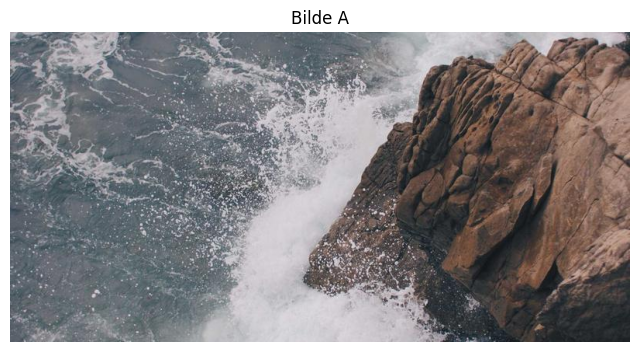

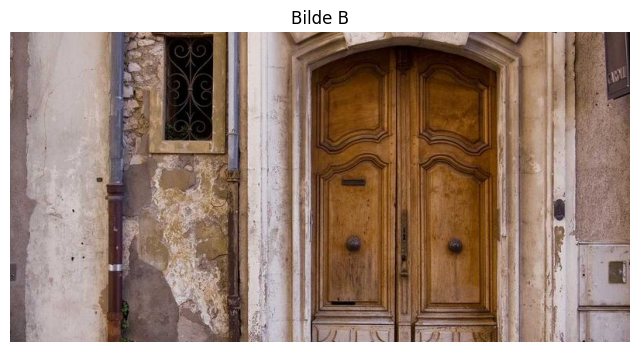

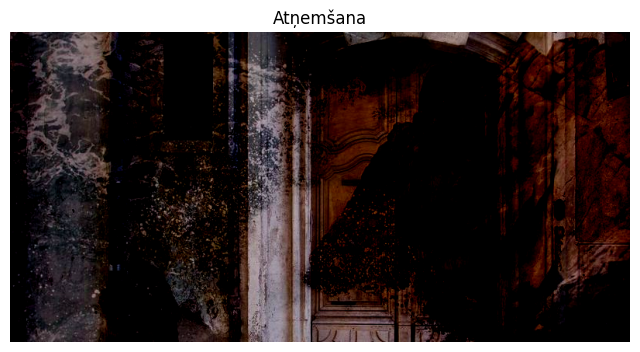

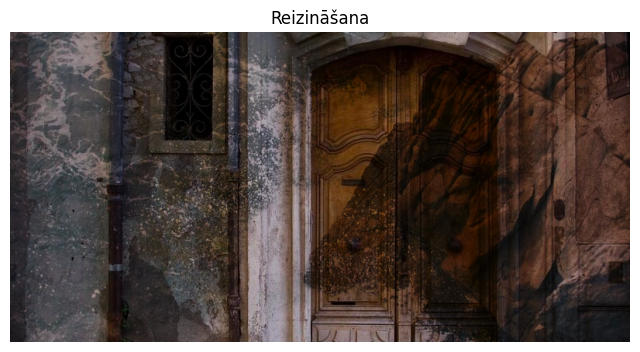

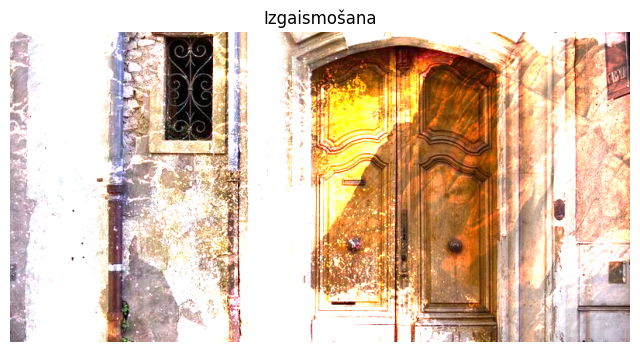

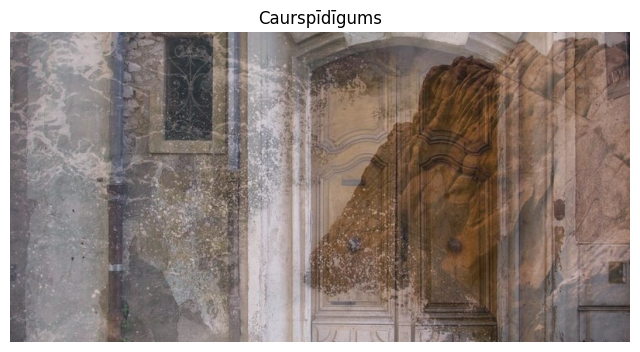

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

uploaded = ["./404-800x400.jpg", "./78-800x400.jpg"]

image1_path = uploaded[0]
image1 = cv2.imread(image1_path)
image2_path = uploaded[1]
image2 = cv2.imread(image2_path)


if image1 is None or image2 is None:
    print("Error loading image!")
    exit()

image1_rgb = cv2.cvtColor(image1, cv2.COLOR_BGR2RGB)
image2_rgb = cv2.cvtColor(image2, cv2.COLOR_BGR2RGB)
w = min(image1_rgb.shape[1], image2_rgb.shape[1])
h = min(image1_rgb.shape[0], image2_rgb.shape[0])
image1_rgb = cv2.resize(image1_rgb, (w, h))
image2_rgb = cv2.resize(image2_rgb, (w, h))

A = image1_rgb.astype(np.float32) / 255.0
B = image2_rgb.astype(np.float32) / 255.0

def display(image, title):
    img_uint8 = (image * 255.0).astype(np.uint8)
    plt.figure(figsize=(8, 6))
    plt.imshow(img_uint8)
    plt.title(title)
    plt.axis('off')
    plt.show()

display(A, "Bilde A")
display(B, "Bilde B")

subtract = np.clip(A + B - 1.0, 0.0, 1.0)
display(subtract, "Atņemšana")

multiply = np.clip(A * B, 0.0, 1.0)
display(multiply, "Reizināšana")

dodge = np.zeros_like(A)
saucejs = 1.0 - A
nulles = (saucejs == 0.0)
nenulles = (saucejs != 0.0)
dodge[nenulles] = B[nenulles]/saucejs[nenulles]
dodge[nulles] = 1.0
dodge = np.clip(dodge, 0.0, 1.0)
display(dodge, "Izgaismošana")


d = 0.5
transparency = d * A + (1 - d) * B
transparency = np.clip(transparency, 0.0, 1.0)
display(transparency, "Caurspīdīgums")

# **Secinājumi**

Nākot no JavaScript, C++ un citām valodām, Python NumPy sistēma ir ļoti pārsteidzoša. Es gaidīju, ka man vajadzēs izmantot `for` ciklus, lai iterētu, bet Python ļauj masīvus saskaitīt un atņemt pa taisno, padarot kodu daudz vienkāršāku, bet mazliet grūtāk saprotamu iesācējām kā man. Tas ir it īpaši redzams `dodge[nenulles] = B[nenulles]/saucejs[nenulles]`, kur es varēju izvairīties no dalīšanas ar nulli apstrādājot tikai nenulles saucēja pikseļus.

Vēl viena daļa, kas mani pārsteidza, ir ērta datu tipu pārveidošana ar `astype` un tad vienkārša masīva dalīšana, lai to normalizētu.

Kopumā esmu apmierināts ar šo darbu un nevaru sagaidīt nākamos.
